In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")

dataset.drop(columns=["User ID","Gender"],inplace=True)

In [3]:
dataset.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


# *insure that the data has not null value*

In [4]:
dataset.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


split data

In [5]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]

scaling

In [6]:
from sklearn.preprocessing import StandardScaler

In [13]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns = x.columns)

# split data into train and test

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.2,random_state=42)

# ***K-NN***

KNN (Classification)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [23]:
knn.score(x_test,y_test)*100

89.375

In [24]:
knn.score(x_train, y_train)

0.8875

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


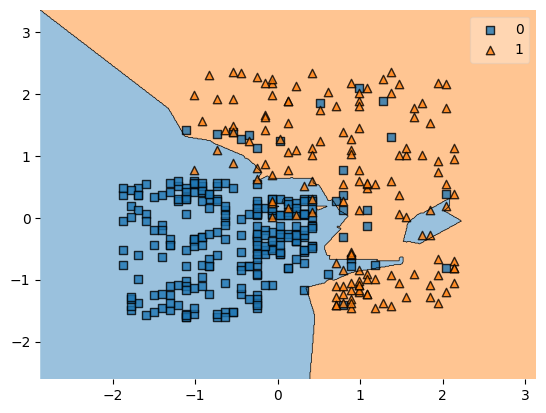

In [25]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()